Correlation analysis

In [ ]:
library(ggplot2)
library(ggrepel)
library(dplyr)
library(DESeq2)
cut_off_q_value=0.05
cut_off_log2FC =0.585
# 先计算ref
org_dat <- read.table('/data2/chenruipu/data/xulingna/snp/bam/output/M18_snp_counts.tsv',sep = '\t', check.names = TRUE,header = TRUE, comment.char = "")
dat<-data.frame(row.names = paste(org_dat$X.chrom,org_dat$pos,org_dat$ref,org_dat$alt,sep=':'))
dat$output1<-org_dat$month18_female_output1_ref_scale+org_dat$month18_female_output1_alt_scale
dat$output2<-org_dat$month18_female_output2_ref_scale+org_dat$month18_female_output2_alt_scale
dat$output3<-org_dat$month18_female_output3_ref_scale+org_dat$month18_female_output3_alt_scale
corr <- cor(dat, method = 'spearman')  #cor函数计算两两样本（列与列）之间的相关系数
library('corrplot')
pdf('sample_cor_M18_female_noinput.pdf',width = 10,height = 10)
corrplot(corr, type = 'upper', tl.col = 'black', tl.srt = 50, addCoef.col = 'white',tl.cex=3.5,number.cex = 3.5,cl.cex = 2 )	
dev.off()

M18 previous menthod detect the fuctional SNPs

In [8]:
library(ggplot2)
library(ggrepel)
library(dplyr)
library(DESeq2)
cut_off_q_value=0.05
cut_off_log2FC =0.585
# 先计算ref
org_dat <- read.table('/data2/chenruipu/data/xulingna/snp/bam/output/M18_snp_counts.tsv',sep = '\t', check.names = TRUE,header = TRUE, comment.char = "")
dat<-data.frame(row.names = paste(org_dat$X.chrom,org_dat$pos,org_dat$ref,org_dat$alt,sep=':'))
dat$input1<-org_dat$Input1_sort_ref+org_dat$Input1_sort_alt
dat$input2<-org_dat$Input2_sort_ref+org_dat$Input2_sort_alt
dat$input3<-org_dat$Input3_sort_ref+org_dat$Input3_sort_alt
dat$output1<-org_dat$X18month_female_output1_ref+org_dat$X18month_female_output1_alt
dat$output2<-org_dat$X18month_female_output2_ref+org_dat$X18month_female_output2_alt
dat$output3<-org_dat$X18month_female_output3_ref+org_dat$X18month_female_output3_alt
coldata <- data.frame(condition = factor(rep(c('input', 'output'), each = 3), levels = c('input', 'output')))
dat[is.na(dat)]<-0
dds <- DESeqDataSetFromMatrix(countData = dat, colData = coldata, design= ~condition)
dds1 <- DESeq(dds, fitType = 'mean', minReplicatesForReplace = 7, parallel = TRUE)
res_ref_alt <- results(dds1, contrast = c('condition', 'output', 'input'))
#fisher test
library(DESeq2)
org_dat <- read.table('/data2/chenruipu/data/xulingna/snp/bam/output/M18_snp_counts.tsv',sep = '\t', check.names = TRUE,header = TRUE, comment.char = "")
dat<-data.frame(row.names = paste(org_dat$X.chrom,org_dat$pos,org_dat$ref,org_dat$alt,sep=':'))
dat$input_ref<-org_dat$Input1_sort_ref+org_dat$Input2_sort_ref+org_dat$Input3_sort_ref
dat$input_alt<-org_dat$Input1_sort_alt+org_dat$Input2_sort_alt+org_dat$Input3_sort_alt
dat$out_ref<-org_dat$X18month_female_output1_ref+org_dat$X18month_female_output2_ref+org_dat$X18month_female_output3_ref
dat$out_alt<-org_dat$X18month_female_output1_alt+org_dat$X18month_female_output2_alt+org_dat$X18month_female_output3_alt
dat <- dat %>%  
  mutate_all(~ ifelse(. < 50, NaN, .))  

Fisher_test<-function(x) {
	if (any(is.na(x)))
	{
		result<-"NaN"
	}
	else
	{
		result<-chisq.test(matrix(x,nrow=2))$p.value
	}

	return(result)
}
fisher_result<-apply(dat,1,function(x) Fisher_test(c(x[1:4])))
fisher_result<-data.frame(fisher_result)
fisher_result$fisher_result<-as.double(fisher_result$fisher_result)
res_ref_alt<-data.frame(res_ref_alt)
res_ref_alt<-merge(res_ref_alt,fisher_result,by='row.names',all=T)
padj_cutoff<-0.05
dat$log2FoldChange.y<-log2(dat$out_alt/dat$out_ref)
dat$log2FoldChange.x<-log2(dat$input_alt/dat$input_ref)
dat$Row.names<-rownames(dat)
res_ref_alt<-merge(res_ref_alt,dat,by='Row.names',all =TRUE)
res_ref_alt$LFC_dif<-res_ref_alt$log2FoldChange.y-res_ref_alt$log2FoldChange.x
res_ref_alt$fdr<-p.adjust(res_ref_alt$fisher_result,method='BH')
res_ref_alt$Sig<- 'no'
res_ref_alt$Sig = ifelse(abs(res_ref_alt$LFC_dif)>=0.585&(abs(res_ref_alt$log2FoldChange)>0.585&res_ref_alt$padj<0.05)&
						res_ref_alt$fdr<padj_cutoff,   
                      ifelse(res_ref_alt$LFC_dif > 0 ,'Up','Down'),'no')
write.csv(res_ref_alt,'M18_female_snp_old_methond.csv')


converting counts to integer mode

estimating size factors

estimating dispersions

gene-wise dispersion estimates: 124 workers

mean-dispersion relationship

final dispersion estimates, fitting model and testing: 124 workers




Down   no   Up 
 221 3789  198 

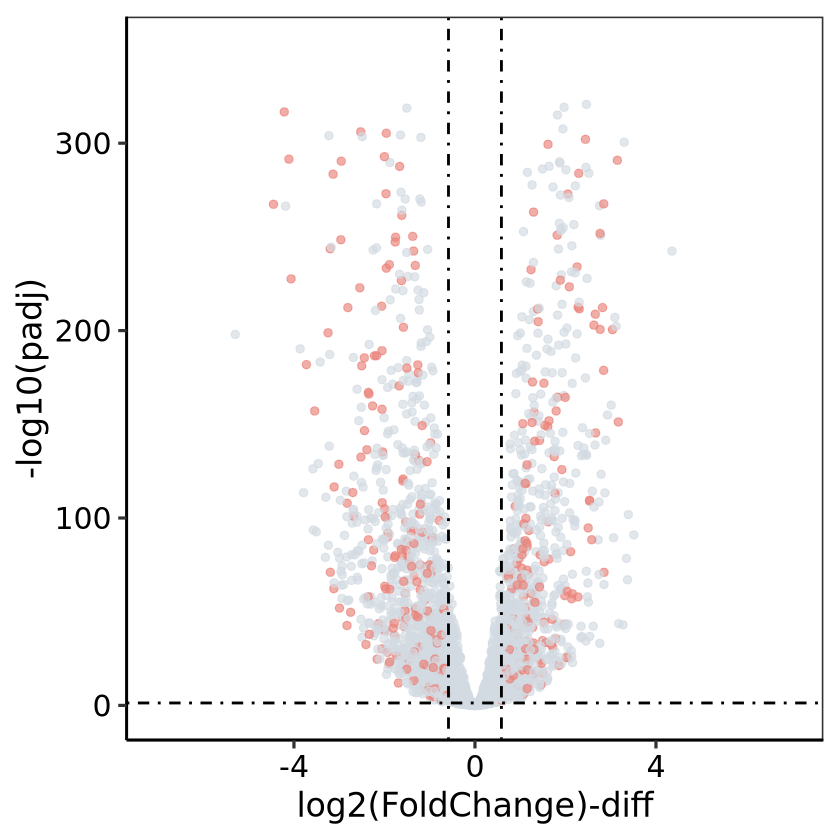

In [10]:
library(ggplot2)
library(ggrepel)
library(dplyr)
library(DESeq2)

# 阈值设置
cut_off_q_value <- 0.05
cut_off_log2FC <- 0.585
padj_cutoff <- 0.05

# 数据读取与过滤
res_ref_alt <- read.csv('M18_female_snp_old_methond.csv')
table(res_ref_alt$Sig)
res_ref_alt <- res_ref_alt %>% 
  filter(Sig != 'NA', fdr != 0)
#6699CC #d2dae2 #EA8379
# 绘图
p <- ggplot(res_ref_alt, aes(x = LFC_dif, y = -log10(fdr), colour = Sig)) +
  geom_point(alpha = 0.65, size = 2) +
  scale_color_manual(
    values = c("#EA8379", "#d2dae2","#EA8379"),
  ) +
  xlim(c(-7, 7)) +
  ylim(c(-1, 350)) +
  geom_vline(xintercept = c(-0.585, 0.585), lty = 4, col = "black", lwd = 0.8) +
  geom_hline(yintercept = -log10(padj_cutoff), lty = 4, col = "black", lwd = 0.8) +
  labs(
    x = "log2(FoldChange)-diff",
    y = "-log10(padj)"
    # title = "M18_female snp effective previous method"
  ) +
  theme_bw(base_size = 20) +
  theme(
    panel.grid = element_blank(),
    axis.line = element_line(color = "black", size = 0.8),
    axis.text = element_text(size = 18, color = "black"),
    axis.title.y = element_text(size = 20, face = "plain"),
    axis.title.x = element_text(size = 20, face = "plain"),
    plot.title = element_text(size = 22, face = "bold", hjust = 0.5),
    legend.position = "none",
    legend.title = element_blank(),
    legend.text = element_text(size = 18)
  )
print(p)
# 保存
ggsave('M18_old_method.pdf', plot = p, height = 8, width = 8)


SNPs overlap in different strategies

In [ ]:
library(VennDiagram)
venn.diagram(  
  x = list( M18_old$Row.names,M18_new$Row.names),
 category.names = c("Previous_method", "Current_method"),  
  filename = 'M18_overlap.png',  # 如果你想将韦恩图保存为文件，可以指定文件名  
  imagetype = 'png',
  resolution = 1000,
  fill = c("#F7Cf50",'#6495ED'),
   alpha = 0.50,
   cex = 0.5,
   cat.cex = 0.5,
   cat.default.pos = "text",
   output=TRUE,
   #main='method overlap'
)

category of the SNPs

Warning message:
“程辑包‘ggplot2’是用R版本4.3.3 来建造的”


Warning message:
“程辑包‘scales’是用R版本4.3.2 来建造的”


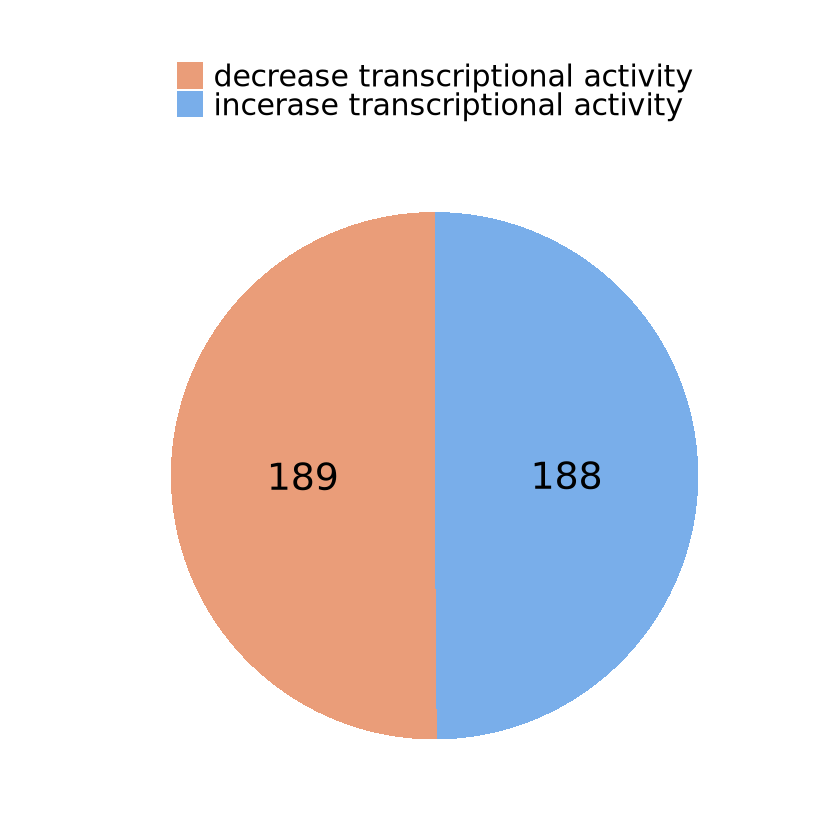

In [19]:
library(ggplot2)
library(scales)  # 用于显示颜色
library(ggsci)

# 绘图
ggplot(old_inf, aes(x = "", y = Freq, fill = Var1)) +
  geom_bar(stat = "identity", width = 0.5, position = "stack") +  
  coord_polar(theta = "y") + 
  labs(x = "", y = "", title = "") +
  geom_text(aes(label = Freq), position = position_stack(vjust = 0.5), size = 8) +  # 字体加大
  scale_fill_manual(values =c("#ea9d79","#79aeea") ) +  # #79d2ea
  theme_bw() +
  theme(
    axis.ticks = element_blank(),
    axis.text.x = element_blank(),
    panel.grid = element_blank(),
    panel.border = element_blank(),
    legend.title = element_blank(),
    legend.position = "top",
    legend.direction = "vertical",
    legend.text = element_text(size = 18),       # 图例字体加大
    plot.title = element_text(size = 22, face = "plain")
  )

# 保存
ggsave("M18_female_old_type.pdf", height = 6, width = 6)


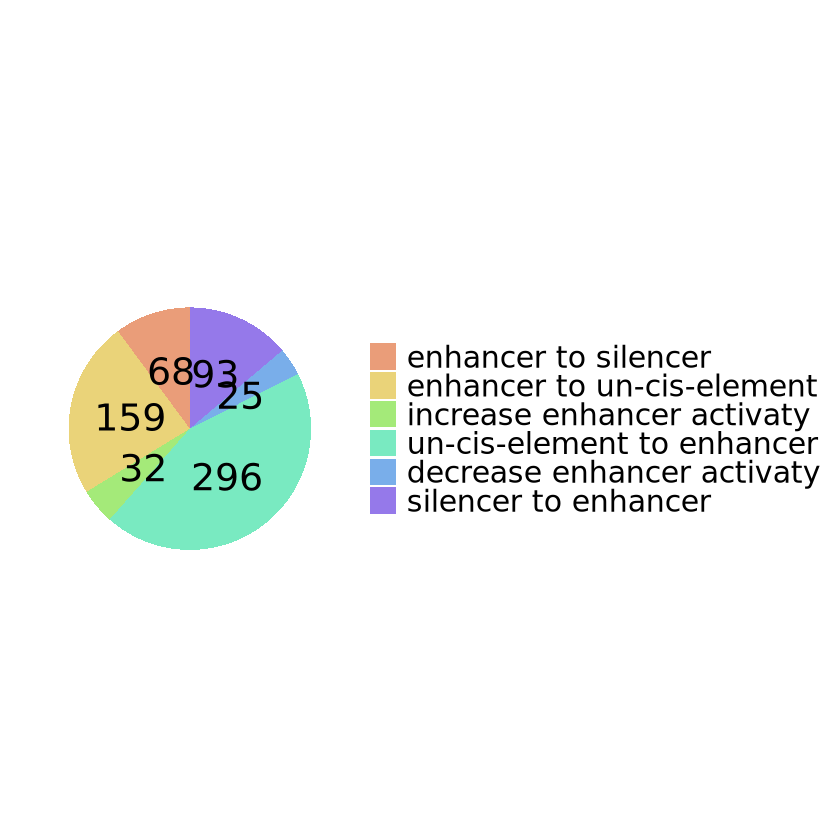

In [37]:
library(ggplot2)
library(ggsci)

# Var1 按字母顺序排列
new_inf$Var1 <- factor(new_inf$Var1, levels = c('enhancer to silencer','enhancer to un-cis-element','increase enhancer activaty','increase silencer activaty','un-cis-element to enhancer','un-cis-element to silencer','decrease enhancer activaty','decrease silencer activaty','silencer to enhancer','silencer to un-cis-element'))

# 绘制饼图
ggplot(new_inf, aes(x = "", y = Freq, fill = Var1)) +
  geom_bar(stat = "identity", width = 0.5, position = "stack") +  
  coord_polar(theta = "y") + 
  labs(x = "", y = "", title = "") +
  geom_text(aes(label = Freq), position = position_stack(vjust = 0.5), size = 8) +
  scale_fill_manual(values = c('#ea9d79','#ead379','#a4ea79','#79eac1','#79aeea','#9579ea','#e479ea','#946470','#ee6f6f','#c599c6'))+
  theme_bw() +
  theme(
    axis.ticks = element_blank(),
    axis.text.x = element_blank(),
    panel.grid = element_blank(),
    panel.border = element_blank(),
    legend.title = element_blank(),
    legend.position = "right",
    legend.text = element_text(size = 18),
    plot.title = element_text(size = 22, face = "bold")
  )

# 保存 PDF
ggsave('M18_female_new_type_legend.pdf', width = 6, height = 6)


male enahcner鉴定

In [ ]:
library(ggplot2)
library(ggrepel)
library(dplyr)
library(DESeq2)
cut_off_q_value=0.05
cut_off_log2FC =0.585
# 先计算ref
org_dat <- read.table('/data2/chenruipu/data/xulingna/snp/bam/output/M18_snp_counts.tsv',sep = '\t', check.names = TRUE,header = TRUE, comment.char = "")
dat<-data.frame(row.names = paste(org_dat$X.chrom,org_dat$pos,org_dat$ref,org_dat$alt,sep=':'))
dat$input1<-org_dat$Input1_sort_ref
dat$input2<-org_dat$Input2_sort_ref
dat$input3<-org_dat$Input3_sort_ref
# dat$input4<-org_dat$Input1_sort_ref
# dat$input5<-org_dat$Input2_sort_ref
# dat$input6<-org_dat$Input3_sort_ref
dat$output1<-org_dat$X18month_female_output1_ref
dat$output2<-org_dat$X18month_female_output2_ref
dat$output3<-org_dat$X18month_female_output3_ref
coldata <- data.frame(condition = factor(rep(c('input', 'output'), each = 3), levels = c('input', 'output')))
dat[is.na(dat)]<-0


dds <- DESeqDataSetFromMatrix(countData = dat, colData = coldata, design= ~condition)

dds1 <- DESeq(dds, fitType = 'mean', minReplicatesForReplace = 7, parallel = TRUE)

res_ref <- results(dds1, contrast = c('condition', 'output', 'input'))
ref_counts<-counts(dds1,normalized=TRUE)
ref_counts<-data.frame(ref_counts)
dat<-data.frame(row.names = paste(org_dat$X.chrom,org_dat$pos,org_dat$ref,org_dat$alt,sep=':'))
dat$input1<-org_dat$Input1_sort_alt
dat$input2<-org_dat$Input2_sort_alt
dat$input3<-org_dat$Input3_sort_alt

dat$output1<-org_dat$X18month_female_output1_alt
dat$output2<-org_dat$X18month_female_output2_alt
dat$output3<-org_dat$X18month_female_output3_alt
coldata <- data.frame(condition = factor(rep(c('input', 'output'), each = 3), levels = c('input', 'output')))
dat[is.na(dat)]<-0


dds <- DESeqDataSetFromMatrix(countData = dat, colData = coldata, design= ~condition)

dds1 <- DESeq(dds, fitType = 'mean', minReplicatesForReplace = 7, parallel = TRUE)

res_alt <- results(dds1, contrast = c('condition', 'output', 'input'))
alt_counts<-counts(dds1,normalized=TRUE)
alt_counts<-data.frame(alt_counts)
#fisher test
library(DESeq2)
org_dat <- read.table('/data2/chenruipu/data/xulingna/snp/bam/output/M18_snp_counts.tsv',sep = '\t', check.names = TRUE,header = TRUE, comment.char = "")
dat<-data.frame(row.names = paste(org_dat$X.chrom,org_dat$pos,org_dat$ref,org_dat$alt,sep=':'))
dat$input_ref<-org_dat$Input1_sort_ref+org_dat$Input2_sort_ref+org_dat$Input3_sort_ref
dat$out_ref<-org_dat$X18month_female_output1_ref+org_dat$X18month_female_output2_ref+org_dat$X18month_female_output3_ref
dat$input_alt<-org_dat$Input1_sort_alt+org_dat$Input2_sort_alt+org_dat$Input3_sort_alt
dat$out_alt<-org_dat$X18month_female_output1_alt+org_dat$X18month_female_output2_alt+org_dat$X18month_female_output3_alt
dat <- dat %>%  
  mutate_all(~ ifelse(. < 50, NaN, .))  

Fisher_test<-function(x) {
	if (any(is.na(x)))
	{
		result<-"NaN"
	}
	else
	{
		result<-chisq.test(matrix(x,nrow=2))$p.value
	}

	return(result)
}
fisher_result<-apply(dat,1,function(x) Fisher_test(c(x[1:4])))

fisher_result<-data.frame(fisher_result)
fisher_result$fisher_result<-as.double(fisher_result$fisher_result)
res_ref_alt<-merge(data.frame(res_ref),data.frame(res_alt),by='row.names',all=T)
rownames(res_ref_alt)<-res_ref_alt$Row.names
res_ref_alt<-merge(res_ref_alt,fisher_result,by='row.names',all=T)
res_ref_alt<-res_ref_alt[,unique(names(res_ref_alt)),drop=FALSE]
padj_cutoff<-0.05
res_ref_alt$LFC_dif<-res_ref_alt$log2FoldChange.y-res_ref_alt$log2FoldChange.x
res_ref_alt$padj<-p.adjust(res_ref_alt$fisher_result,method='BH')
res_ref_alt$Sig = ifelse(abs(res_ref_alt$LFC_dif)>=0.585&((abs(res_ref_alt$log2FoldChange.x)>0.585&res_ref_alt$padj.x<0.05)|(abs(res_ref_alt$log2FoldChange.y)>0.585&res_ref_alt$padj.y<0.05))&
						res_ref_alt$padj<padj_cutoff,   
                      ifelse(res_ref_alt$LFC_dif > 0 ,'Up','Down'),'no')
write.csv(res_ref_alt,'M18_female_snp_respectively.csv')



Down   no   Up 
 449 2799  601 

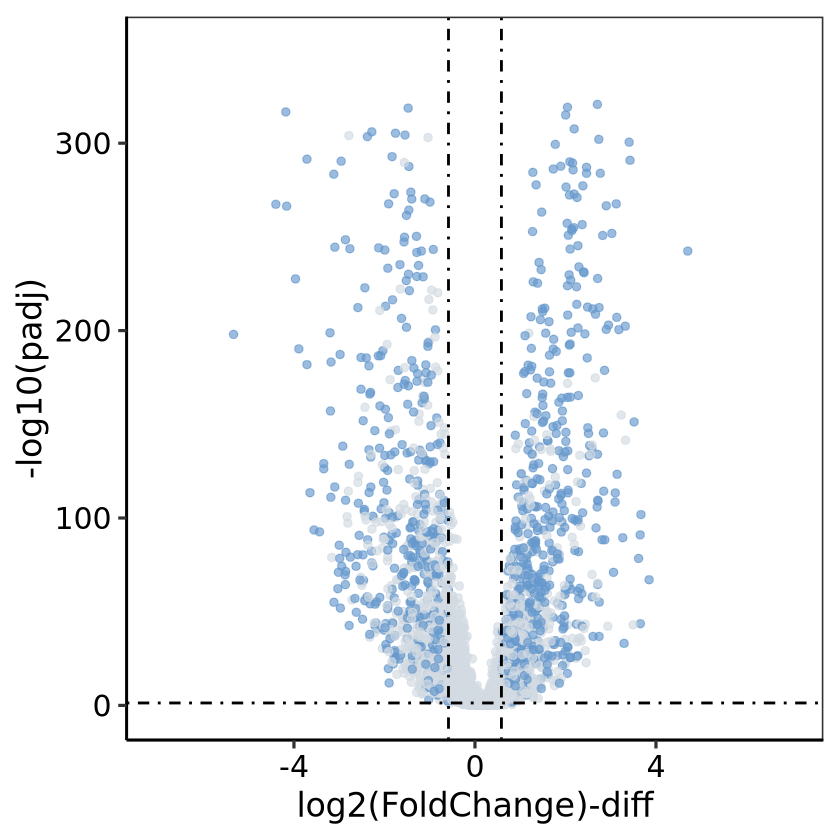

In [12]:
library(ggplot2)
library(ggrepel)
library(dplyr)
library(DESeq2)

# 阈值设置
cut_off_q_value <- 0.05
cut_off_log2FC <- 0.585
padj_cutoff <- 0.05

# 数据读取与过滤
res_ref_alt <- read.csv('M18_female_snp_respectively.csv')
table(res_ref_alt$Sig)
res_ref_alt <- res_ref_alt %>% 
  filter(Sig != 'NA', padj != 0)


# 绘图
p <- ggplot(res_ref_alt, aes(x = LFC_dif, y = -log10(padj), colour = Sig)) +
  geom_point(alpha = 0.65, size = 2) +
  scale_color_manual(values = c("#6699CC", "#d2dae2","#6699CC")) +
  xlim(c(-7, 7)) +
  ylim(c(-1, 350)) +
  geom_vline(xintercept = c(-0.585, 0.585), lty = 4, col = "black", lwd = 0.8) +
  geom_hline(yintercept = -log10(padj_cutoff), lty = 4, col = "black", lwd = 0.8) +
  labs(
    x = "log2(FoldChange)-diff",
    y = "-log10(padj)"
    # title = "M18_female snp effective previous method"
  ) +
  theme_bw(base_size = 20) +
  theme(
    panel.grid = element_blank(),
    axis.line = element_line(color = "black", size = 0.8),
    axis.text = element_text(size = 18, color = "black"),
    axis.title.y = element_text(size = 20, face = "plain"),
    axis.title.x = element_text(size = 20, face = "plain"),
    plot.title = element_text(size = 22, face = "bold", hjust = 0.5),
    legend.position = "none",
    legend.title = element_blank(),
    legend.text = element_text(size = 18)
  )

print(p)
# 保存
ggsave('M18_female_snp_respectively.pdf', plot = p, height = 8, width = 8)


target gene type

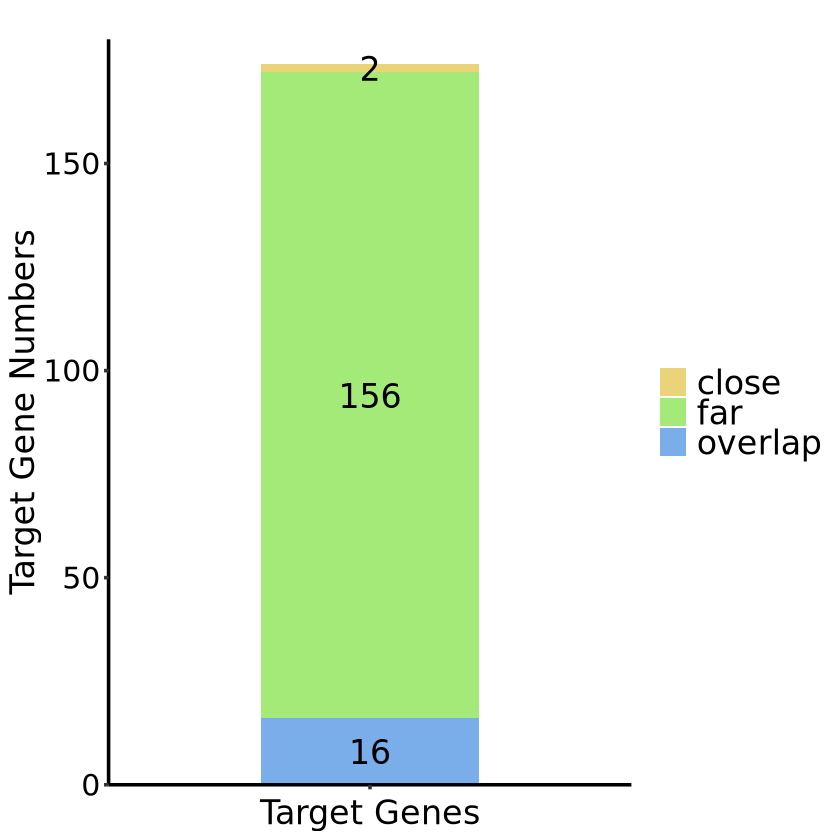

In [14]:
library(RColorBrewer)
snp_eff_info<-read.table(file='loop_result/enhancer_snp_distype.tsv',sep='\t',header = 1)
snp_eff_info<- data.frame(table(snp_eff_info$dis_to_gene))
snp_eff_info$sex <-'female'
names(snp_eff_info)<-c('Type','Freq','sex')
library(ggplot2)
ggplot(snp_eff_info, aes(x=sex, y=Freq, group=Type)) +
    geom_bar(stat="identity", position="stack", width =0.5 ,aes(fill=Type)) +
    labs(x = "Target Genes",y = "Target Gene Numbers",title="") + #设置横纵坐标的题目，可以和前面的不一样
    scale_y_continuous(expand = c(0,0),limits = c(0, 180)) + #使每根柱子延伸到0，也可以不用
    theme_classic() +
    theme(legend.text=element_text(size=20),
          legend.title=element_text(size=13)) +
    theme(axis.title = element_text(size =20),
          axis.text.y=element_text(size=18,color = "black"),
          axis.text.x = element_text(size = 0,hjust=0.5,vjust=0.5), #angle这些是设置横坐标的角度和位置
          axis.line = element_line(size = 1),
          axis.ticks = element_line(size = 1)) + 
	theme(legend.title = element_blank()) +
    scale_fill_manual(values = c("#ead379", "#a4ea79", "#79aeea"))+#选柱子的颜色
	geom_text(aes(label=Freq), position=position_stack(vjust=0.5), size=7) #在柱子上添加数值
ggsave('M18_target_Gene_type_stage.pdf',width = 5,height = 5)

In [52]:
library(motifbreakR)
library(BSgenome.Hsapiens.UCSC.hg38)
all_snp<-readRDS('all_snp.rds')
pdf('chr4_119525893_A_G_TF.pdf',width = 10,height = 30)
plotMB(all_snp,rsid='chr4:119525893:A:G',effect = "strong")
dev.off()

png 
  2

SNPs input output bar plot

Warning message:
“程辑包‘ggplot2’是用R版本4.3.3 来建造的”
Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


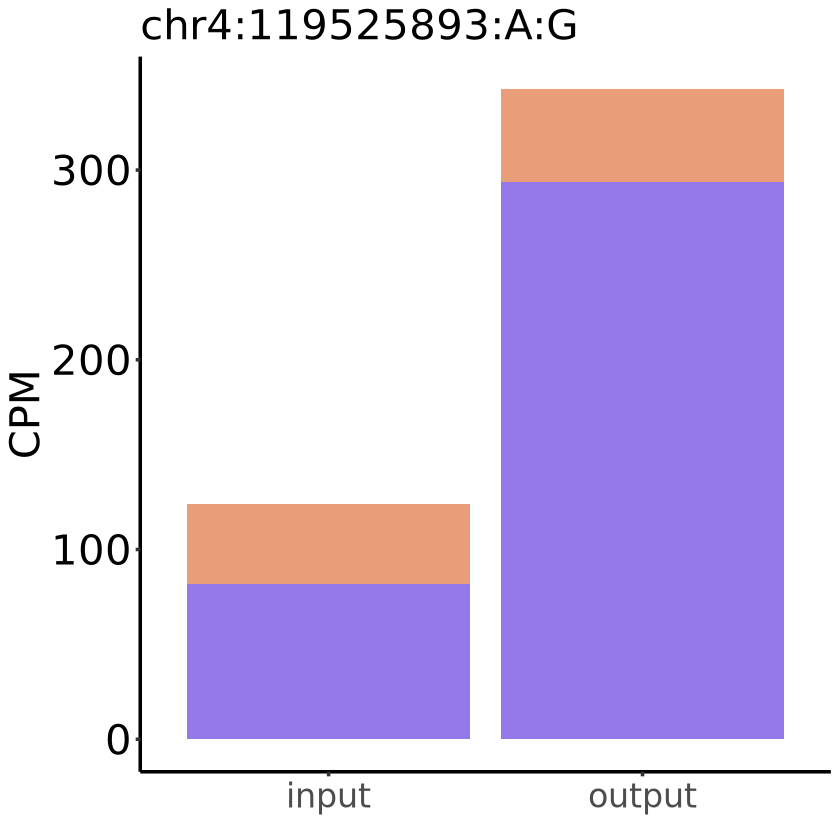

In [ ]:
# 加载ggplot2包
library(ggplot2)
library(RColorBrewer)
org_dat <- read.table('/data2/chenruipu/data/xulingna/snp/bam/output/M18_snp_counts.tsv',sep = '\t', check.names = TRUE,header = TRUE, comment.char = "")
dat<-data.frame(row.names = paste(org_dat$X.chrom,org_dat$pos,org_dat$ref,org_dat$alt,sep=':'))

dat$input_ref_scale<-org_dat$input1_ref_scale+org_dat$input2_ref_scale+org_dat$input3_ref_scale
dat$input_alt_scale<-org_dat$input1_alt_scale+org_dat$input2_alt_scale+org_dat$input3_alt_scale
dat$out_ref_scale<-org_dat$month18_female_output1_ref_scale+org_dat$month18_female_output2_ref_scale+org_dat$month18_female_output3_ref_scale
dat$out_alt_scale<-org_dat$month18_female_output1_alt_scale+org_dat$month18_female_output2_alt_scale+org_dat$month18_female_output3_alt_scale
# chr1:11228561:G:A chr1:11106245:C:T chr1:11059078:G:A
snp<-'chr4:119525893:A:G'
data <- data.frame(
  Category =c("input", "input", "output","output"),
  Subcategory = c("ref","alt","ref","alt"),
  Value = unlist(unname(c(dat[snp,])))
  )

# 绘制堆叠柱状图
ggplot(data, aes(x = Category, y = Value, fill = Subcategory)) +
  geom_bar(stat = "identity", position = "stack",width = 0.9) +  # 使用堆叠柱状图
  scale_fill_manual(values = c("ref" = "#9579ea", "alt" = "#ea9d79"))+
  labs(
    x = "",
    y = "CPM",
    title = snp
  ) +
    theme_classic() +
    theme(legend.text=element_text(size=10),
          legend.position = "none",
          plot.title = element_text(size = 25,face='plain'),
          axis.title.y = element_text(size = 25, face = "plain"),
          axis.text.y=element_text(size=25,color = "black"),
          axis.text.x = element_text(size = 20,hjust=0.5,vjust=0.5), #angle这些是设置横坐标的角度和位置
          axis.line = element_line(size = 1),
          axis.ticks = element_line(size = 1)) 
ggsave(paste0(gsub(':', '_', snp), "_allele_barplot.pdf"), height = 8, width = 6)

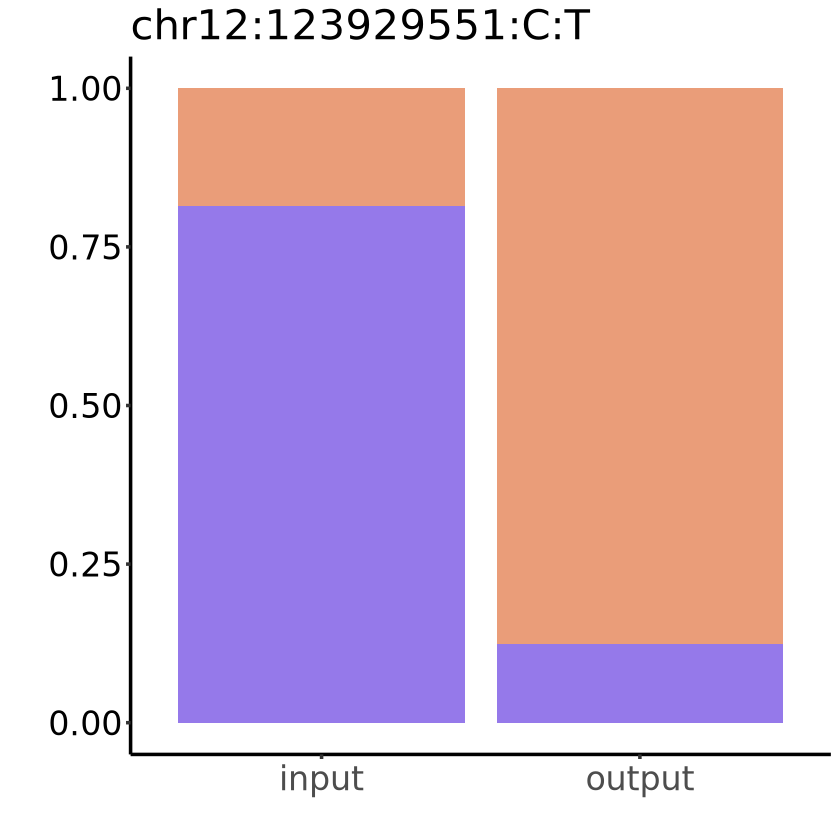

In [30]:

library(ggplot2)
library(RColorBrewer)
library(ggsci)
library(dplyr)

data <- data %>%
  group_by(Category) %>%
  mutate(Frequency = Value / sum(Value))

# #9579ea
ggplot(data, aes(x = Category, y = Frequency, fill = Subcategory)) +
  geom_bar(stat = "identity", position = "stack") +  # 堆叠柱状图
  scale_fill_manual(values = c("ref" = "#9579ea", "alt" = "#ea9d79")) +
  labs(
    x = "",
    y = "",
    fill = "",
    title = snp
  ) +
  theme_classic() +
  theme(
    legend.position = "none",                # 去掉图例
    plot.title = element_text(size = 25, face='plain'),  # 标题字体放大，不加粗
    axis.text.y = element_text(size = 20, color = "black"), 
    axis.text.x = element_text(size = 20, hjust=0.5, vjust=0.5), 
    axis.title.y = element_text(size = 22, face='plain'),
    axis.title.x = element_text(size = 22, face='plain'),
    axis.line = element_line(size = 1),
    axis.ticks = element_line(size = 1)
  )

# 保存为 PDF
ggsave(paste0(gsub(':', '_', snp), "_allele_frq_barplot.pdf"), height = 8, width = 6)

different strategies correlation

In [11]:
M18_old<-read.csv('M18_female_snp_old_methond.csv')
M18_old<-M18_old[(M18_old$Sig!='no'&M18_old$Sig!='NA'),]
M18_new<-read.csv('M18_female_snp_respectively.csv')
M18_new<-M18_new[(M18_new$Sig!='no'&M18_new$Sig!='NA'),]
M18_old<-M18_old[,c('Row.names','LFC_dif')]
M18_new<-M18_new[,c('Row.names','LFC_dif')]
M18_new_old<-merge(M18_old,M18_new,by='Row.names',all=T)
M18_new_old<-na.omit(M18_new_old)
cor(M18_new_old$LFC_dif.x,M18_new_old$LFC_dif.y,use = "pairwise.complete.obs")

[1] 0.9986478

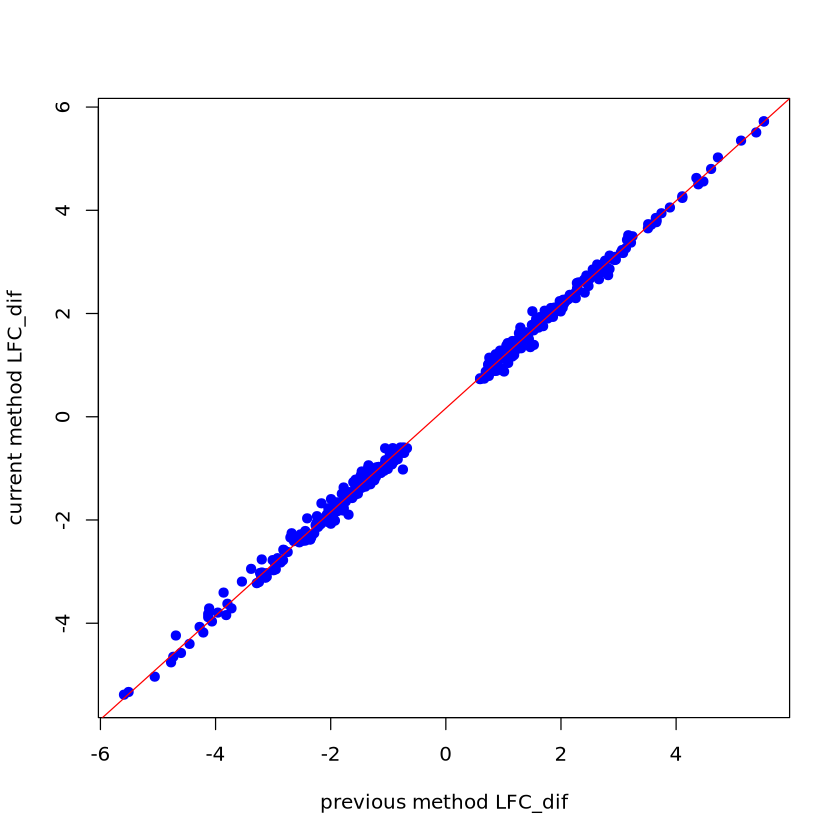

In [14]:
# 绘制散点图
plot(M18_new_old$LFC_dif.x, M18_new_old$LFC_dif.y,
     main = "",  # 图标题
     xlab = "previous method LFC_dif",        # X轴标签
     ylab = "current method LFC_dif",        # Y轴标签
     pch = 19,             # 点的形状（19表示实心圆）
     col = "blue")         # 点的颜色
 
# 可选：添加线性回归线
abline(lm(M18_new_old$LFC_dif.y ~ M18_new_old$LFC_dif.x), col = "red")

slide window 

In [3]:
library(ggplot2)
library(ggrepel)
library(dplyr)
library(DESeq2)
cut_off_q_value=0.05
cut_off_log2FC =0.585
org_dat <- read.table('/data2/chenruipu/data/xulingna/AAV_ITR_0401/aav/AAV_counts.bed',sep = '\t', check.names = TRUE,header = TRUE, comment.char = "")
dat<-data.frame(row.names = org_dat$names)
dat$input1<-org_dat$input_counts
dat$input2<-org_dat$input_counts
dat$input3<-org_dat$input_counts
dat$output1<-org_dat$AAV_1_counts
dat$output2<-org_dat$AAV_2_counts
dat$output3<-org_dat$AAV_3_counts
coldata <- data.frame(condition = factor(rep(c('input', 'output'), each = 3), levels = c('input', 'output')))
dat[is.na(dat)]<-0

#第一步，构建 DESeqDataSet 对象
dds <- DESeqDataSetFromMatrix(countData = dat, colData = coldata, design= ~condition)

#第二步，计算差异倍数并获得 p 值
#备注：parallel = TRUE 可以多线程运行，在数据量较大时建议开启
dds1 <- DESeq(dds, fitType = 'mean', minReplicatesForReplace = 7, parallel = TRUE)

#注意，需将 treat 在前，control 在后，意为 treat 相较于 control 中哪些基因上调/下调
res_ref_alt <- results(dds1, contrast = c('condition', 'output', 'input'))

aav_result<-data.frame(res_ref_alt)

estimating size factors

estimating dispersions

gene-wise dispersion estimates: 124 workers

mean-dispersion relationship

final dispersion estimates, fitting model and testing: 124 workers



In [ ]:
library(ggplot2)
library(ggrepel)
library(dplyr)
library(DESeq2)
cut_off_q_value=0.05
cut_off_log2FC =0.585
org_dat <- read.table('/data2/chenruipu/data/xulingna/AAV_ITR_0401/itr/ITR_counts.csv',sep = ',', check.names = TRUE,header = TRUE, comment.char = "")
dat<-data.frame(row.names = org_dat$index)
dat$input1<-org_dat$ITR.input.bam
dat$input2<-org_dat$ITR.input.bam
dat$input3<-org_dat$ITR.input.bam
dat$output1<-org_dat$ITR.1.merge.bam
dat$output2<-org_dat$ITR.2.merge.bam
dat$output3<-org_dat$ITR.3.merge.bam
coldata <- data.frame(condition = factor(rep(c('input', 'output'), each = 3), levels = c('input', 'output')))
dat[is.na(dat)]<-0

#第一步，构建 DESeqDataSet 对象
dds <- DESeqDataSetFromMatrix(countData = dat, colData = coldata, design= ~condition)

#第二步，计算差异倍数并获得 p 值
#备注：parallel = TRUE 可以多线程运行，在数据量较大时建议开启
dds1 <- DESeq(dds, fitType = 'mean', minReplicatesForReplace = 7, parallel = TRUE)

#注意，需将 treat 在前，control 在后，意为 treat 相较于 control 中哪些基因上调/下调
res_ref_alt <- results(dds1, contrast = c('condition', 'output', 'input'))


ggplot(res_ref_alt, aes(x =res_ref_alt$log2FoldChange, y=-log10(res_ref_alt$padj))) + #x、y轴取值限制，颜色根据"Sig"
geom_point(alpha=0.65, size=2) +  #点的透明度、大小
#scale_color_manual(values=c("#546de5", "#d2dae2","#ff4757")) + xlim(c(-7, 7)) +  #调整点的颜色和x轴的取值范围
ylim(c(-1,500))+#调整点的颜色和x轴的取值范围
geom_vline(xintercept=c(-0.585,0.585),lty=4,col="black",lwd=0.8) + #添加x轴辅助线,lty函数调整线的类型："twodash"、"longdash"、"dotdash"、"dotted"、"dashed"、"solid"、"blank"
geom_hline(yintercept = -log10(cut_off_q_value), lty=4,col="black",lwd=0.8) +  #添加y轴辅助线
labs(x="LFC_dif", y="-log10(padj)") +  #x、y轴标签
#ggtitle("M18_female snp effective previous method") + #标题
theme_bw() + # 主题，help(theme)查找其他个性化设置
theme(plot.title = element_text(hjust = 0.5),
	legend.position="right", 
	legend.title = element_blank()
) 
itr_result<-data.frame(res_ref_alt)

In [4]:
itr_aav_result<-merge(itr_result,aav_result,by='row.names',all.x = TRUE)

Warning message in stat_poly_eq(aes(label = paste(..rr.label.., ..p.value.label.., :
“Ignoring unknown parameters: `label.x.npc` and `label.y.npc`”
`geom_smooth()` using formula = 'y ~ x'


`geom_smooth()` using formula = 'y ~ x'


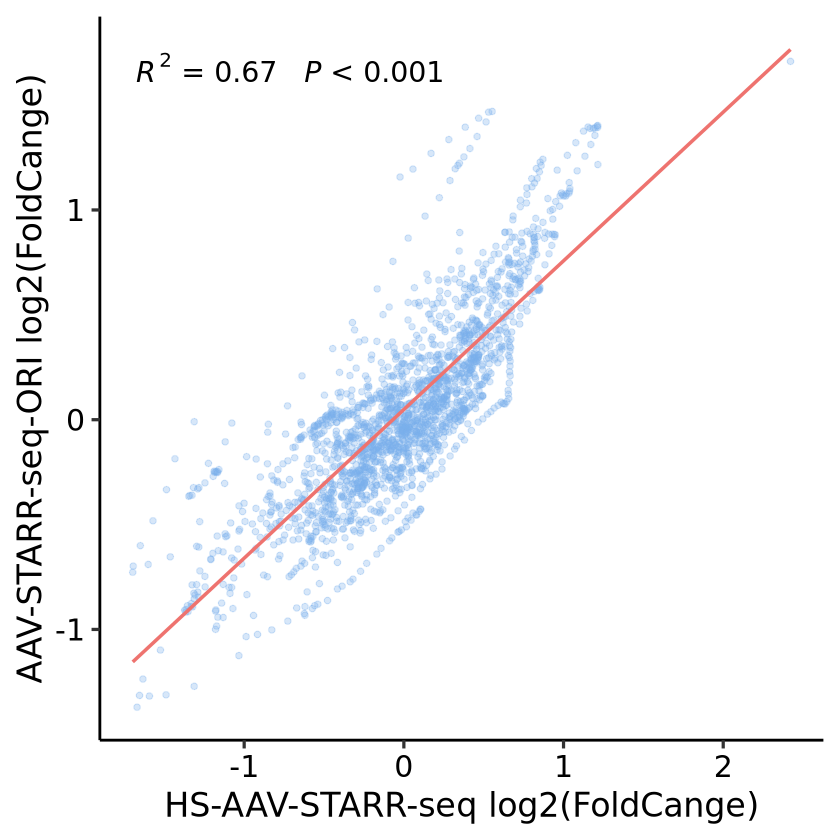

In [6]:
library(ggplot2)
library(ggsci)
library(ggpmisc)
#4fc5a8
p <- ggplot(itr_aav_result, aes(x = log2FoldChange.x, y = log2FoldChange.y)) +
  geom_point(size = 1.5, alpha = 0.3, color = '#79aeea') +   # d3 调色板点
  geom_smooth(method = "lm", se = FALSE, color = '#ee736f', size = 1) +  # 回归线
  labs(
    x = "HS-AAV-STARR-seq log2(FoldCange)",
    y = "AAV-STARR-seq-ORI log2(FoldCange)"
  ) +
  stat_poly_eq(
    aes(label = paste(..rr.label.., ..p.value.label.., sep = "~~~")),
    formula = y ~ x,
    parse = TRUE,
    label.x.npc = "right",
    label.y.npc = 0.95,
    size = 6   # 放大回归方程字体（默认是3.5左右）
  ) +
  theme_classic(base_size = 20) +   # 基础字体整体放大
  theme(
    panel.grid = element_blank(),
    axis.line = element_line(color = "black", size = 0.8),
    axis.text = element_text(size = 18, color = "black"),
    axis.title = element_text(size = 20, face = "plain"),
    plot.title = element_text(size = 22, face = "bold", hjust = 0.5)
  )
ggsave('ORI_ITR_cor.pdf',height = 8,width = 8)
print(p)


In [ ]:

itr_result$Sig<-'HS-AAV-STARR-seq'
aav_result$Sig<-'AAV-STARR-seq-ORI'

itr_aav_ori_result<-rbind(itr_result[c("log2FoldChange", "Sig")],aav_result[c("log2FoldChange", "Sig")])

In [42]:
itr_aav_ori_result$abs_log2FoldChange<-abs(itr_aav_ori_result$log2FoldChange)

Warning message:
"Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`)."
Warning message:
"Removed 1 row containing non-finite outside the scale range (`stat_signif()`)."
Warning message:
"Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`)."
Warning message:
"Removed 1 row containing non-finite outside the scale range (`stat_signif()`)."


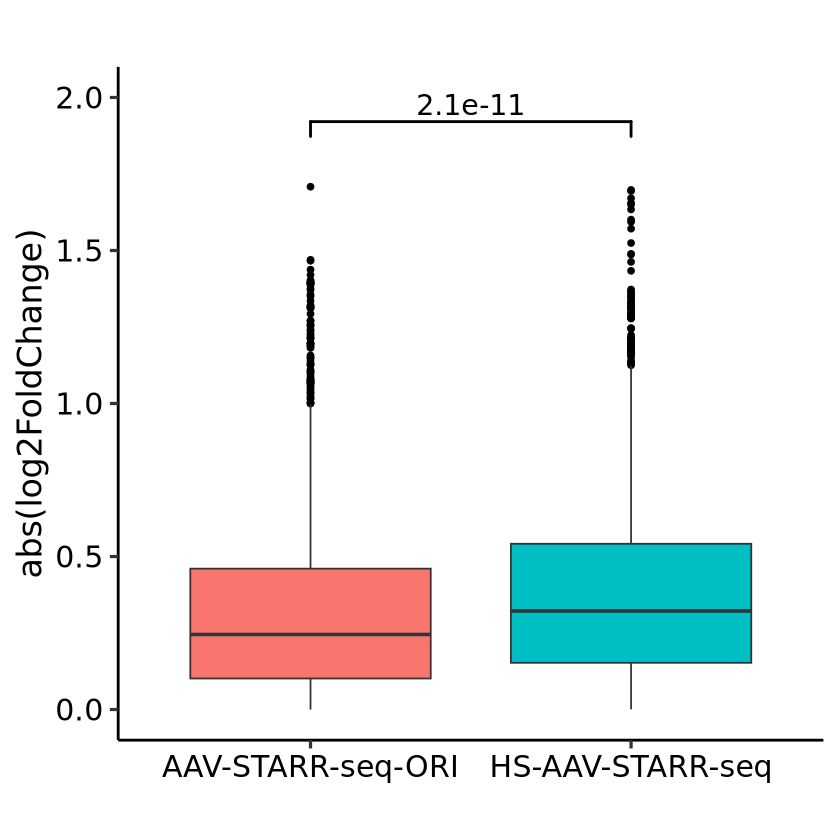

In [68]:
library(ggplot2)
library(ggpubr)
library(ggsci)


ggplot(itr_aav_ori_result, aes(x = Sig, y = abs_log2FoldChange, fill = Sig)) +  
  geom_boxplot(outlier.color = "black") +  
  ylim(0, 2) +
  geom_signif(
    comparisons = list(c("AAV-STARR-seq-ORI", "HS-AAV-STARR-seq")),
    test = t.test,
    y_position = c(1.8),
    tip_length = c(0.02, 0.02),
    size = 0.8,
    color = "black",
    textsize = 6   # 调整显著性标记字体，与上图一致
  ) +
  labs(
    title = "",
    x = "",
    y = "abs(log2FoldChange)",
    fill = ""
  ) +
  guides(fill = "none") +
  theme_classic(base_size = 20) +  # 与散点图统一字体风格
  theme(
    panel.grid = element_blank(),  
    axis.line = element_line(color = "black", size = 0.8),  # 添加黑色坐标轴线
    axis.text = element_text(size = 18, color = "black"),   # 坐标轴刻度文字
    axis.title.y = element_text(size = 20, face = "plain"), # 纵轴标题不加粗
    axis.title.x = element_text(size = 20, face = "plain"), 
    plot.title = element_text(size = 22, face = "bold", hjust = 0.5)
  )
ggsave('ORI_ITR_boxplot.pdf',height = 8,width = 8)